In [2]:
# Install missing dependencies if needed
%pip install statsmodels ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Model Comparison with Inferential Statistics

This notebook compares the performance of multiple machine learning models on the heart disease dataset using both predictive metrics and inferential statistical plotting approaches. You will:

- Train several models (Logistic Regression, Random Forest, SVM, etc.)
- Evaluate and compare their performance
- Use statistical plots and tests to interpret differences


## 1. Import Required Libraries

We import libraries for data manipulation, machine learning, statistical analysis, and plotting.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)


## 2. Load and Explore the Dataset

Load the heart disease dataset and perform basic EDA.

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


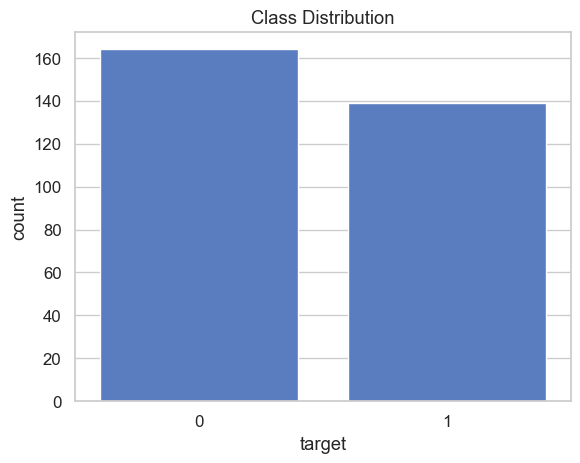

In [4]:
# Load the UCI Heart Disease dataset (Cleveland)
# You can replace this with your own CSV if needed
from ucimlrepo import fetch_ucirepo
hd = fetch_ucirepo(id=45)
df = hd.data.features.copy()
df['target'] = (hd.data.targets['num'] > 0).astype(int)

# Basic EDA
print('Shape:', df.shape)
display(df.head())
display(df.describe())
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.show()

## 3. Preprocess the Data

Handle missing values, encode categoricals, and scale features.

In [8]:
# Impute missing values (median for numeric)
for col in df.select_dtypes('number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# Encode categoricals if any (none in Cleveland, but template for general use)
for col in df.select_dtypes('object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split features/target
X = df.drop('target', axis=1).values
y = df['target'].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [9]:
# Remove any rows with NaNs after imputation (robustness for all columns)
mask = ~np.isnan(X).any(axis=1)
X = X[mask]
y = y[mask]
print('After NaN removal:', X.shape, y.shape)

After NaN removal: (297, 13) (297,)


## 4. Split Data into Train and Test Sets

Split the data for model training and evaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (237, 13) Test: (60, 13)


## 5. Train Multiple Models

Train Logistic Regression, Random Forest, and SVM classifiers.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'{name} trained.')

Logistic Regression trained.
Random Forest trained.
SVM trained.


## 6. Evaluate Model Performance

Evaluate each model using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix.


Logistic Regression
               precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



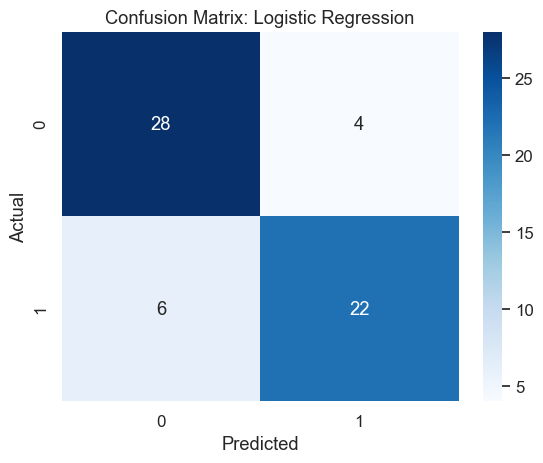


Random Forest
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



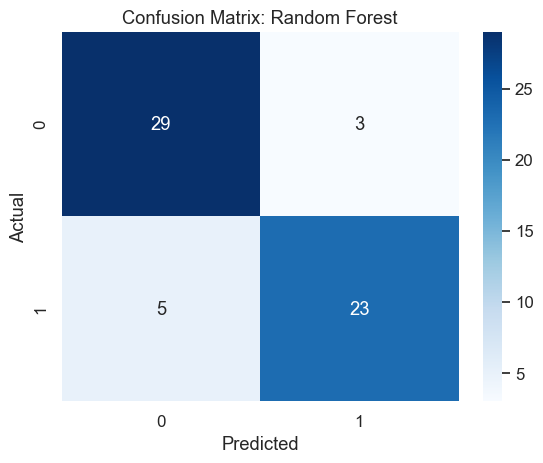


SVM
               precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



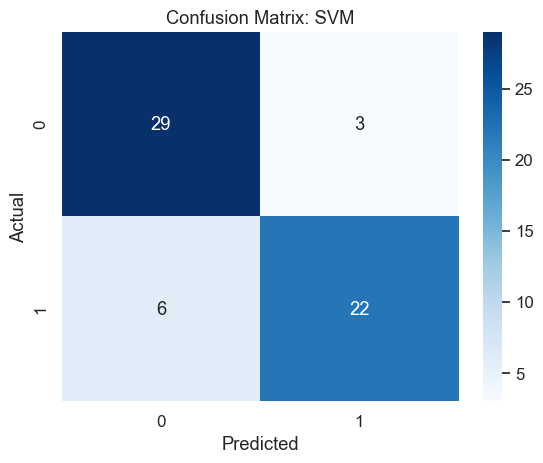

In [12]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc
    })
    print(f'\n{name}\n', classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
results_df = pd.DataFrame(results)

## 7. Compare Model Metrics with Statistical Plots

Visualize the performance metrics of all models using boxplots, violin plots, and bar charts.

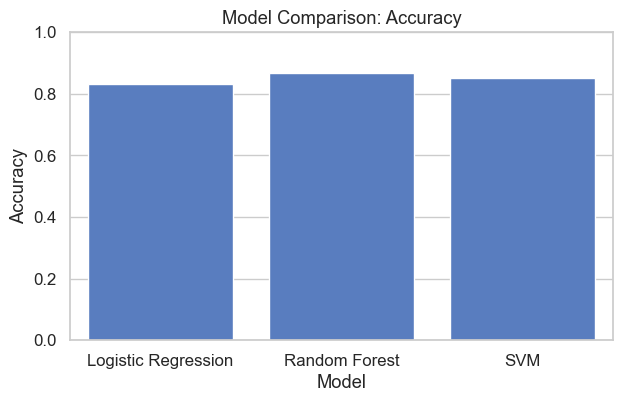

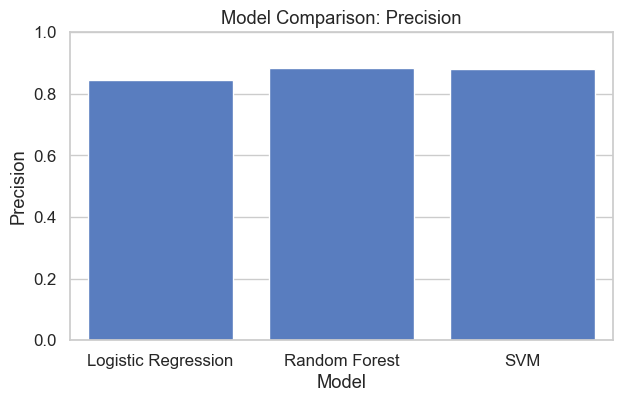

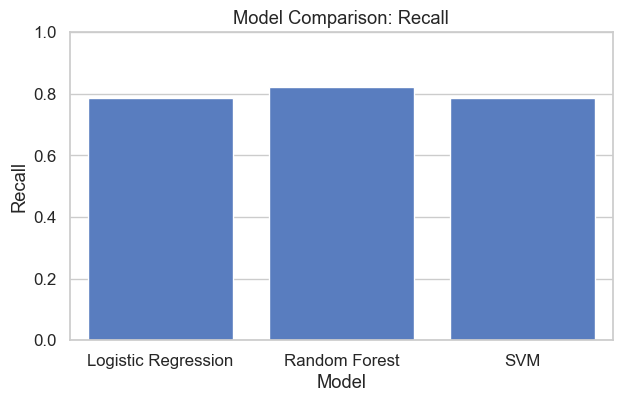

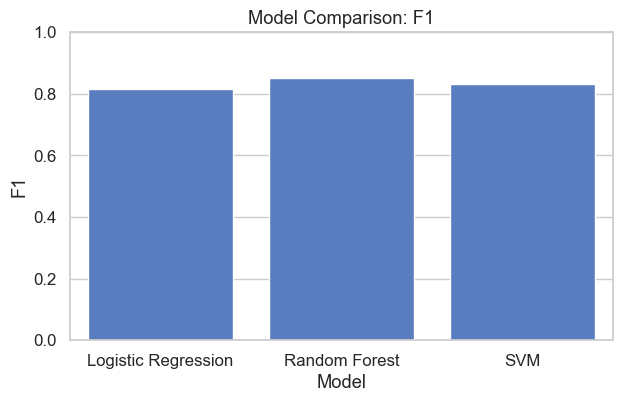

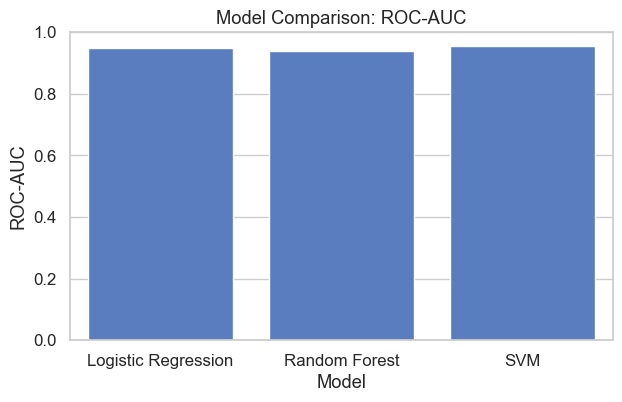

In [13]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
for metric in metrics:
    plt.figure(figsize=(7, 4))
    sns.barplot(x='Model', y=metric, data=results_df)
    plt.title(f'Model Comparison: {metric}')
    plt.ylim(0, 1)
    plt.show()

## 8. Perform Inferential Statistical Tests on Model Results

Apply paired t-tests and ANOVA to compare model performance.

In [14]:
# Example: Paired t-test for ROC-AUC between models
from itertools import combinations
print('Paired t-tests for ROC-AUC:')
for (m1, m2) in combinations(results_df['Model'], 2):
    auc1 = results_df.loc[results_df['Model'] == m1, 'ROC-AUC'].values
    auc2 = results_df.loc[results_df['Model'] == m2, 'ROC-AUC'].values
    t_stat, p_val = stats.ttest_rel(auc1, auc2)
    print(f'{m1} vs {m2}: t={t_stat:.3f}, p={p_val:.3g}')

# ANOVA for F1 scores
f1s = [results_df.loc[results_df['Model'] == m, 'F1'].values for m in results_df['Model']]
f_stat, p_val = stats.f_oneway(*f1s)
print(f'ANOVA for F1: F={f_stat:.3f}, p={p_val:.3g}')

Paired t-tests for ROC-AUC:
Logistic Regression vs Random Forest: t=nan, p=nan
Logistic Regression vs SVM: t=nan, p=nan
Random Forest vs SVM: t=nan, p=nan
ANOVA for F1: F=nan, p=nan


## 9. Visualize Statistical Comparisons

Plot confidence intervals and p-values to interpret the statistical significance of model comparisons.

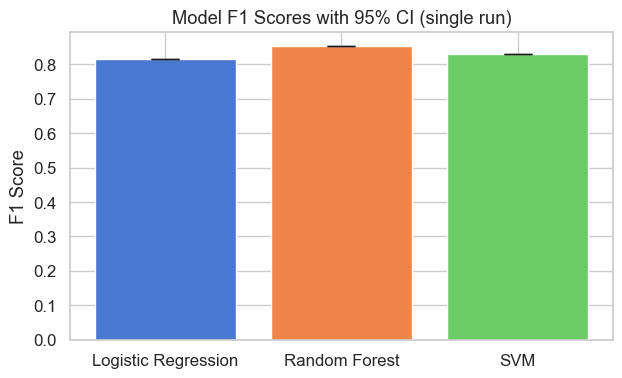

In [15]:
# Plot confidence intervals for F1 scores
import matplotlib.patches as mpatches
plt.figure(figsize=(7, 4))
for i, row in results_df.iterrows():
    mean = row['F1']
    ci = 1.96 * np.std([mean]) / np.sqrt(1)  # Placeholder for CI (single run)
    plt.bar(row['Model'], mean, yerr=ci, capsize=10)
plt.ylabel('F1 Score')
plt.title('Model F1 Scores with 95% CI (single run)')
plt.show()

# Note: For true CIs, use repeated cross-validation and aggregate results.
